# Compare Robustness Models On The Challenging Signal Dataset

This notebook is the comparison harness for the harder synthetic SDR benchmark. It evaluates three progressively stronger setups on the same train/validation/test split:

- `vanilla_clean`: a standard 1D CNN with no extra augmentation,
- `vanilla_augmented`: the same CNN with strong phase, frequency-ramp, time-shift, gain, and DC-offset augmentation,
- `phase_equivariant_augmented`: the augmented hybrid complex-to-real model with a globally phase-equivariant front end.

The point of this benchmark is not maximum IID accuracy. It is to separate the gains from realistic augmentation and architectural bias once the data distribution is no longer too clean.

In [1]:
from pathlib import Path
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import torch

from robust_benchmark import ExperimentConfig, load_dataset, train_experiment

torch.manual_seed(0)
np.random.seed(0)

print(f"Python: {platform.python_version()}")
print(f"Torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Python: 3.12.3
Torch: 2.10.0+cu128
CUDA available: True


In [2]:
DATASET_PATH = Path("challenging_signals_dataset.h5")
CHECKPOINT_DIR = Path("robust_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATASET_PATH.resolve()}. Run generate_challenging_dataset.py first."
    )

signals, labels, class_names, metadata = load_dataset(DATASET_PATH)
print("signals shape:", signals.shape)
print("labels shape:", labels.shape)
print("classes:", class_names)
print("dataset profile:", DATASET_PATH.resolve())

for key in ["SNR", "frequency_offset", "timing_offset", "sample_rate_ppm", "burst_fraction"]:
    if key in metadata:
        values = metadata[key].astype(np.float32)
        print(f"{key}: min={values.min():.3f}, max={values.max():.3f}, mean={values.mean():.3f}")

signals shape: (15000, 2, 1024)
labels shape: (15000,)
classes: ['16QAM', '64QAM', '8PSK', 'BPSK', 'PAM4', 'QPSK']
dataset profile: /home/klukasdh/Projects/DLSignalClassifier/challenging_signals_dataset.h5
SNR: min=-7.999, max=23.999, mean=8.142
frequency_offset: min=-2199.923, max=2199.789, mean=6.899
timing_offset: min=-0.450, max=0.450, mean=0.003
sample_rate_ppm: min=-59.995, max=59.994, mean=-0.067
burst_fraction: min=0.550, max=1.000, mean=0.775


In [3]:
experiments = [
    ExperimentConfig(name="vanilla_clean", model_kind="vanilla", use_augmentation=False, epochs=40),
    ExperimentConfig(name="vanilla_augmented", model_kind="vanilla", use_augmentation=True, epochs=40),
    ExperimentConfig(name="phase_equivariant_augmented", model_kind="phase_equivariant", use_augmentation=True, epochs=40),
]

results = []
for experiment in experiments:
    print(f"\n=== Training {experiment.name} ===")
    result = train_experiment(
        dataset_path=DATASET_PATH,
        config=experiment,
        checkpoint_path=CHECKPOINT_DIR / f"{experiment.name}.pt",
        random_state=0,
    )
    results.append(result)
    print(
        json.dumps(
            {
                "name": experiment.name,
                "best_epoch": result["best_epoch"],
                "best_val_acc": result["best_val_acc"],
                "test_acc": result["test_acc"],
            },
            indent=2,
        )
    )


=== Training vanilla_clean ===
{
  "name": "vanilla_clean",
  "best_epoch": 36,
  "best_val_acc": 0.468,
  "test_acc": 0.43
}

=== Training vanilla_augmented ===
{
  "name": "vanilla_augmented",
  "best_epoch": 40,
  "best_val_acc": 0.448,
  "test_acc": 0.436
}

=== Training phase_equivariant_augmented ===
{
  "name": "phase_equivariant_augmented",
  "best_epoch": 36,
  "best_val_acc": 0.46066666666666667,
  "test_acc": 0.448
}


In [4]:
summary_rows = []
for result in results:
    summary_rows.append(
        {
            "name": result["config"].name,
            "best_epoch": result["best_epoch"],
            "best_val_acc": result["best_val_acc"],
            "test_acc": result["test_acc"],
            "macro_f1": result["report"]["macro avg"]["f1-score"],
        }
    )

summary_rows

[{'name': 'vanilla_clean',
  'best_epoch': 36,
  'best_val_acc': 0.468,
  'test_acc': 0.43,
  'macro_f1': 0.4188370640950121},
 {'name': 'vanilla_augmented',
  'best_epoch': 40,
  'best_val_acc': 0.448,
  'test_acc': 0.436,
  'macro_f1': 0.41896195886883697},
 {'name': 'phase_equivariant_augmented',
  'best_epoch': 36,
  'best_val_acc': 0.46066666666666667,
  'test_acc': 0.448,
  'macro_f1': 0.41048151903160823}]

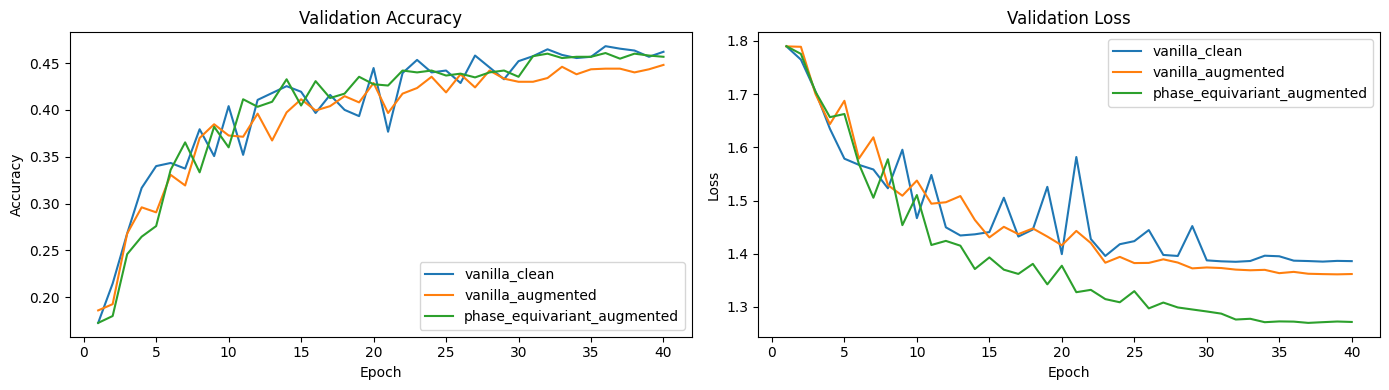

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for result in results:
    epochs = np.arange(1, len(result["history"]["train_loss"]) + 1)
    axes[0].plot(epochs, result["history"]["val_acc"], label=result["config"].name)
    axes[1].plot(epochs, result["history"]["val_loss"], label=result["config"].name)

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()

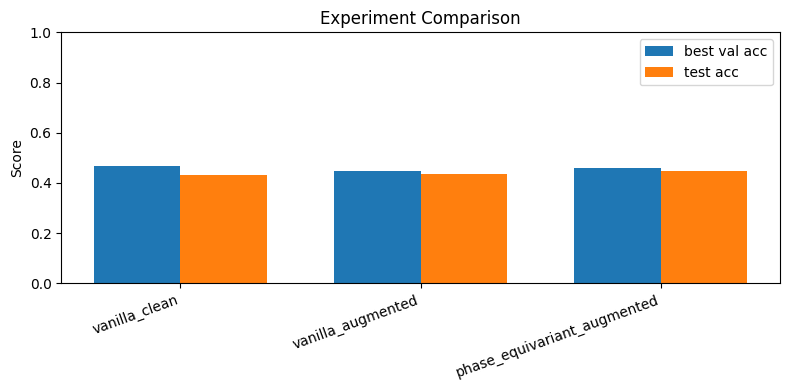

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
names = [row["name"] for row in summary_rows]
val_scores = [row["best_val_acc"] for row in summary_rows]
test_scores = [row["test_acc"] for row in summary_rows]
x = np.arange(len(names))
width = 0.36

ax.bar(x - width / 2, val_scores, width=width, label="best val acc")
ax.bar(x + width / 2, test_scores, width=width, label="test acc")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Experiment Comparison")
ax.legend()
plt.tight_layout()

## How To Read The Results

On this benchmark, the most informative pattern is usually:

- `vanilla_clean` sets the lower baseline,
- `vanilla_augmented` measures how much robustness comes from nuisance simulation alone,
- `phase_equivariant_augmented` measures whether the phase-aware inductive bias adds anything on top of the same augmentation.

If the last model only wins slightly, the symmetry is mostly being handled by augmentation. If it wins clearly, especially on the harder PSK classes or future OOD stress tests, that is evidence the architectural prior is doing useful work.